<div style="border: 5px solid #2e3b4e; border-radius: 35px; padding: 20px; font-family: Arial, sans-serif; line-height: 1.6; background-color: white; color: #2e3b4e;">
  <h2>Overview of Kaggle Competition: Playground Series S5E1</h2>
  <ol>
    <li><b>Objective:</b> Predict the future sales of a retail chain using past sales data, taking into account factors like date, store, and product details.</li>
    <li><b>Data:</b>
      <ul>
        <li>Training data includes historical sales records with features such as date, store, and product category.</li>
        <li>Test data contains similar features but without target sales values for prediction.</li>
      </ul>
    </li>
    <li><b>Evaluation Metric:</b> Submissions are evaluated using Root Mean Squared Error (RMSE) on the test dataset. Lower RMSE indicates better performance.</li>
    <li><b>Competition Focus:</b>
      <ul>
        <li>Focus on time-series forecasting techniques and handling structured data with seasonal and promotional patterns.</li>
        <li>Leverage feature engineering, including encoding categorical data, handling missing values, and incorporating external features like holidays and events.</li>
      </ul>
    </li>
    <li><b>Learning Opportunity:</b> This competition provides an excellent opportunity to practice and learn time-series forecasting and regression models. It also allows experimentation with different feature engineering approaches to improve predictions.</li>
  </ol>
</div>


<a id="dataset-analysis"></a>
<p style="padding:30px;background-color:#2e3b4e;margin:0;color:#e8e8e8;font-family:Arial,sans-serif;font-size:250%;text-align:center;border-radius:10px;overflow:hidden;font-weight:800">
    🚀 Libraries 🚀

In [75]:
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt
import statsmodels.api as sm

from sklearn.model_selection import KFold, train_test_split

from lightgbm import LGBMRegressor
from lightgbm import early_stopping
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.model_selection import KFold

import optuna

import warnings
warnings.filterwarnings('ignore')


<a id="dataset-analysis"></a>
<p style="padding:30px;background-color:#2e3b4e;margin:0;color:#e8e8e8;font-family:Arial,sans-serif;font-size:250%;text-align:center;border-radius:10px;overflow:hidden;font-weight:800">
    🚀 Data Exploring + Statistical Analysis  🚀

In [76]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
sub = pd.read_csv('sample_submission.csv')

In [77]:
train.head()

,id,date,country,store,product,num_sold
0,0,2010-01-01,Canada,Discount Stickers,Holographic Goose,NaN
1,1,2010-01-01,Canada,Discount Stickers,Kaggle,973.0
2,2,2010-01-01,Canada,Discount Stickers,Kaggle Tiers,906.0
3,3,2010-01-01,Canada,Discount Stickers,Kerneler,423.0
4,4,2010-01-01,Canada,Discount Stickers,Kerneler Dark Mode,491.0


In [78]:
print("Shape of traing data:",train.shape)
print("Shape of testing data:", test.shape)

Shape of traing data: (230130, 6)
Shape of testing data: (98550, 5)


In [79]:
test.head()

,id,date,country,store,product
0,230130,2017-01-01,Canada,Discount Stickers,Holographic Goose
1,230131,2017-01-01,Canada,Discount Stickers,Kaggle
2,230132,2017-01-01,Canada,Discount Stickers,Kaggle Tiers
3,230133,2017-01-01,Canada,Discount Stickers,Kerneler
4,230134,2017-01-01,Canada,Discount Stickers,Kerneler Dark Mode


In [80]:
train.isna().sum().sort_values(ascending=False)

num_sold    8871
id             0
date           0
country        0
store          0
product        0
dtype: int64

In [81]:
train.nunique()

id          230130
date          2557
country          6
store            3
product          5
num_sold      4037
dtype: int64

In [82]:
train.describe()

,id,num_sold
count,230130.000000,221259.000000
mean,115064.500000,752.527382
std,66432.953062,690.165445
min,0.000000,5.000000
25%,57532.250000,219.000000
50%,115064.500000,605.000000
75%,172596.750000,1114.000000
max,230129.000000,5939.000000


In [83]:
train.describe(include=['object'])

,date,country,store,product
count,230130,230130,230130,230130
unique,2557,6,3,5
top,2010-01-01,Canada,Discount Stickers,Holographic Goose
freq,90,38355,76710,46026


In [84]:
train['country'].value_counts()

country
Canada       38355
Finland      38355
Italy        38355
Kenya        38355
Norway       38355
Singapore    38355
Name: count, dtype: int64

In [85]:
train = train.dropna()
test = test.dropna()

In [86]:
train.head()

,id,date,country,store,product,num_sold
1,1,2010-01-01,Canada,Discount Stickers,Kaggle,973.0
2,2,2010-01-01,Canada,Discount Stickers,Kaggle Tiers,906.0
3,3,2010-01-01,Canada,Discount Stickers,Kerneler,423.0
4,4,2010-01-01,Canada,Discount Stickers,Kerneler Dark Mode,491.0
5,5,2010-01-01,Canada,Stickers for Less,Holographic Goose,300.0


#### num_sold

In [87]:
def num_stats(data, col):
    stats_col = data[col].describe().to_frame().transpose()
    stats_col['missing'] = data[col].isnull().sum()
    stats_col.index.name = col
    return stats_col

<a id="dataset-analysis"></a>
<p style="padding:30px;background-color:#2e3b4e;margin:0;color:#e8e8e8;font-family:Arial,sans-serif;font-size:250%;text-align:center;border-radius:10px;overflow:hidden;font-weight:800">
    🚀 EDA Plots 🚀

<div style="border: 5px solid #2e3b4e; border-radius: 35px; padding: 20px; font-family: Arial, sans-serif; line-height: 1.6; background-color: white; color: #2e3b4e;">
  <h2>Total Sales by Country - Bar Plot</h2>
  <p>This plot visualizes the total sales by country. The data is grouped by <strong>country</strong>, and total sales are calculated by summing the <strong>num_sold</strong> values for each country.</p>
  <ul>
    <li><strong>x-axis:</strong> Country names</li>
    <li><strong>y-axis:</strong> Total products sold in each country</li>
    <li><strong>Annotations:</strong> Sales values displayed on top of each bar</li>
  </ul>
  <p>The bar plot uses the "magma" color palette, and x-axis labels are rotated for readability.</p>
</div>


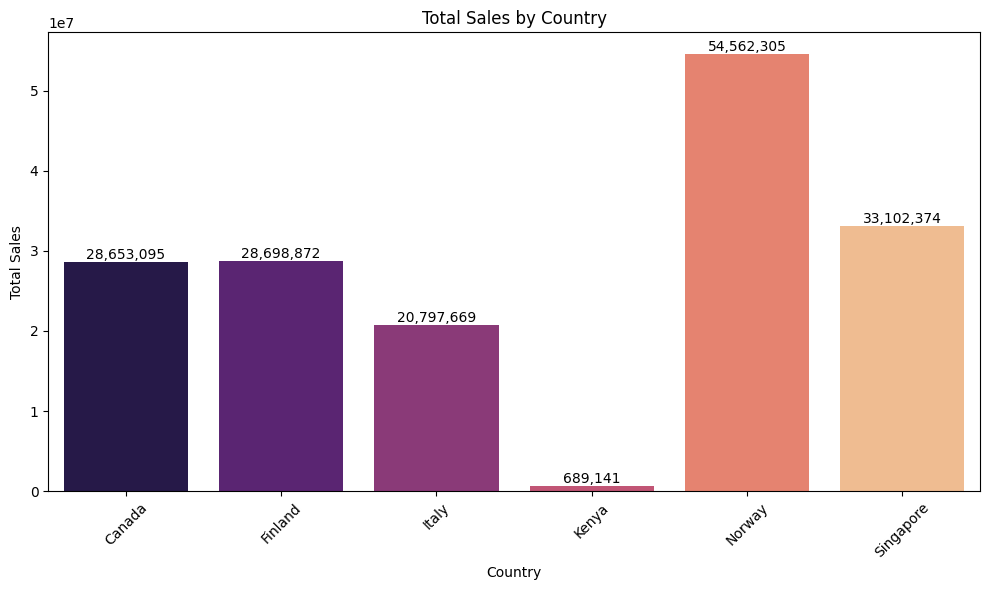

In [88]:
country_sales = train.groupby('country')['num_sold'].sum()

# Visualization
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=country_sales.index, y=country_sales.values, palette='magma')
plt.title("Total Sales by Country")
plt.xlabel("Country")
plt.ylabel("Total Sales")

# Adding values on the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():,.0f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<div style="border: 5px solid #2e3b4e; border-radius: 35px; padding: 20px; font-family: Arial, sans-serif; line-height: 1.6; background-color: white; color: #2e3b4e;">
  <h2>Logarithmic Transformation of Sales Data</h2>
  <p>This process visualizes the distribution of the logarithmic transformation of the number of products sold (`num_sold + 1`) to better understand its distribution.</p>
  
  <h3>Steps Taken:</h3>
  <ul>
    <li><strong>Logarithmic Transformation:</strong> Applied the natural logarithm to `num_sold + 1` using <code>np.log1p()</>.</li>
    <li><strong>Histogram Plot:</strong> Created a histogram with an overlaid Kernel Density Estimate (KDE) to show the distribution.</li>
  </ul>

  <h3>Visualization:</h3>
  <p>The following plot shows the distribution of the logarithmic transformation of the sales data:</p>
  <img src="path_to_your_generated_plot.png" alt="Logarithmic Transformation of Sales Data" style="max-width: 100%; height: auto;">
</div>


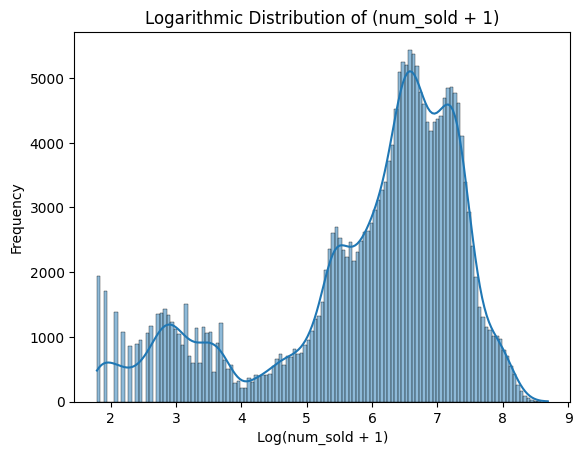

In [89]:
sns.histplot(data=train, x=np.log1p(train['num_sold']), kde=True)
plt.title("Logarithmic Distribution of (num_sold + 1)")
plt.xlabel("Log(num_sold + 1)")
plt.ylabel("Frequency")
plt.show()

<div style="border: 5px solid #2e3b4e; border-radius: 35px; padding: 20px; font-family: Arial, sans-serif; line-height: 1.6; background-color: white; color: #2e3b4e;">
  <h2>Total Sales Over Time</h2>
  <p>This plot visualizes the total number of products sold over time. The x-axis represents the date, and the y-axis shows total sales, helping to identify trends, seasonal effects, or significant changes in sales performance.</p>
</div>


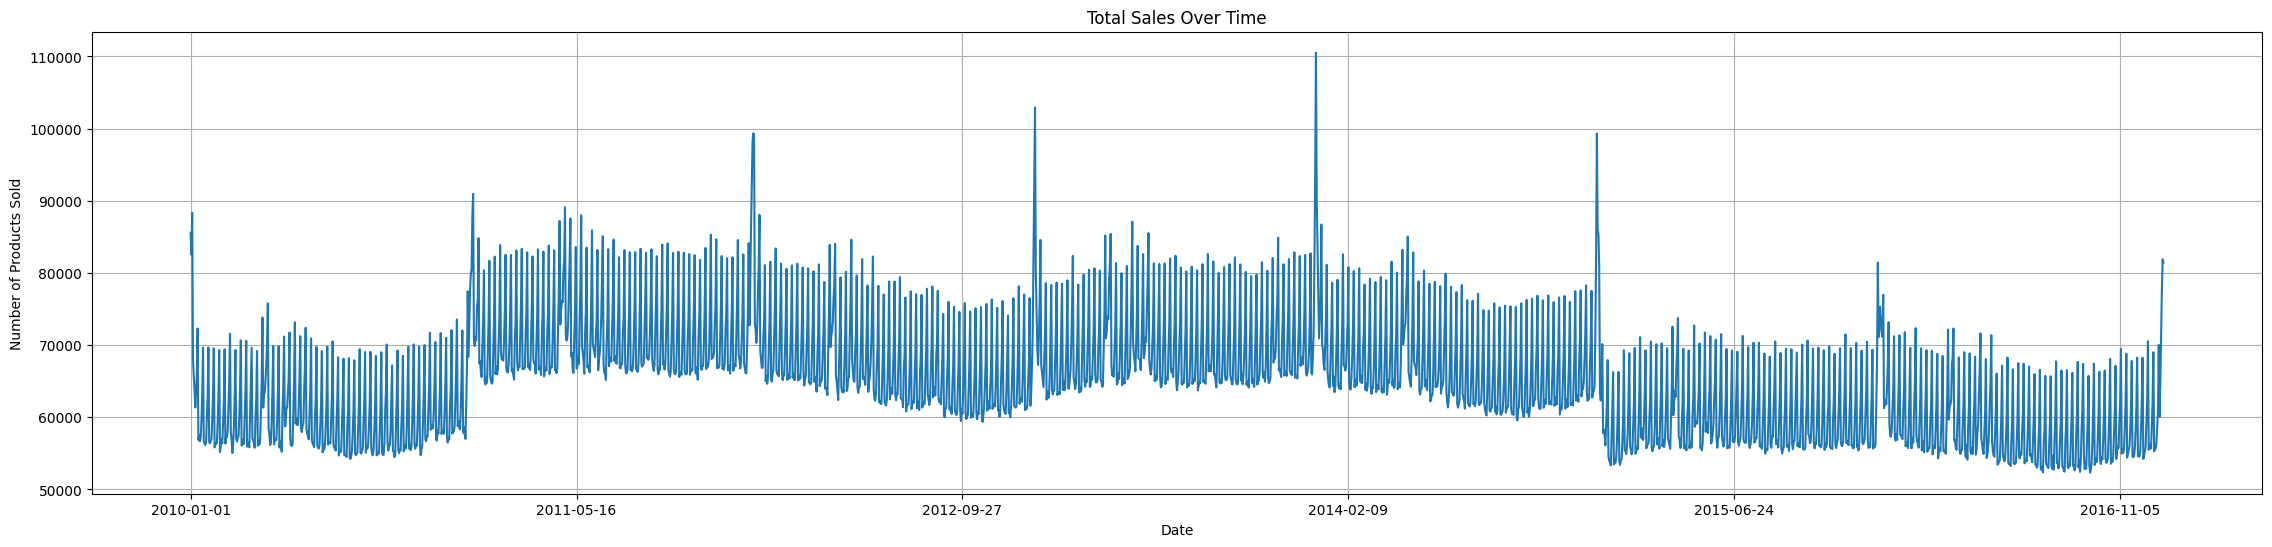

In [90]:
# 1. Total sales over time
plt.figure(figsize=(28, 6))
train.groupby('date')['num_sold'].sum().plot(title='Total Sales Over Time', xlabel='Date', ylabel='Number of Products Sold')
plt.grid()
plt.show()

<div style="border: 5px solid #2e3b4e; border-radius: 35px; padding: 20px; font-family: Arial, sans-serif; line-height: 1.6; background-color: white; color: #2e3b4e;">
  <h2>Sales Trends by Country</h2>
  <p>This line plot illustrates product sales trends over time, categorized by country. Each line represents total sales in a specific country on a given date. The x-axis shows the date, and the y-axis shows the total products sold. This visualization allows for cross-country comparisons and highlights sales patterns, peaks, or dips in performance for each region.</p>
</div>


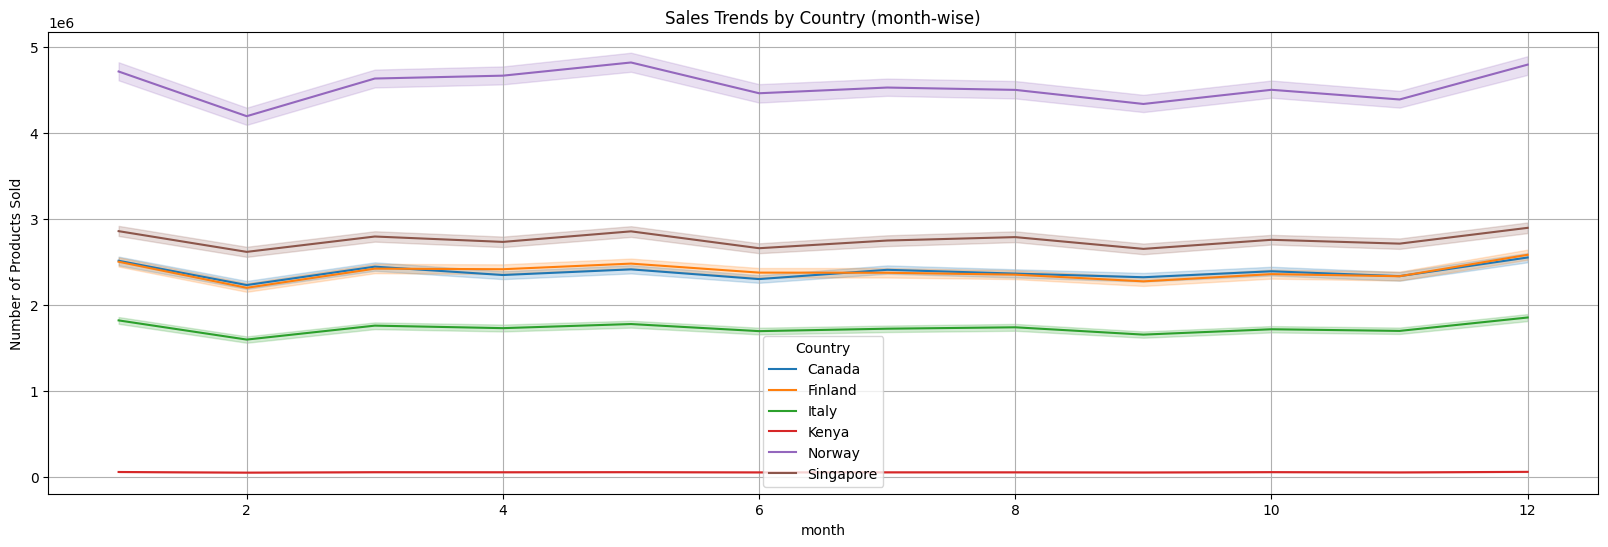

CPU times: total: 2.91 s
Wall time: 3 s


In [91]:
%%time
# 2. Sales trends by country (month-wise)
train['date'] = pd.to_datetime(train['date'], errors='coerce')  # Ensure 'date' is datetime type
train['month'] = train['date'].dt.month  # Extract year from the date column

plt.figure(figsize=(20, 6))
sns.lineplot(data=train, x='month', y='num_sold', hue='country', estimator='sum')
plt.title('Sales Trends by Country (month-wise)')
plt.xlabel('month')
plt.ylabel('Number of Products Sold')
plt.legend(title='Country')
plt.grid()
plt.show()


<div style="border: 5px solid #2e3b4e; border-radius: 35px; padding: 20px; font-family: Arial, sans-serif; line-height: 1.6; background-color: white; color: #2e3b4e;">
  <h2>Sales Trends by Product</h2>
  <p>This line plot shows the trends in product sales over time, categorized by product type. Each line represents a specific product, with total units sold on each date. The x-axis shows the date, and the y-axis shows the number of products sold. The visualization allows for comparisons between products and helps identify patterns or shifts in consumer preferences.</p>
</div>


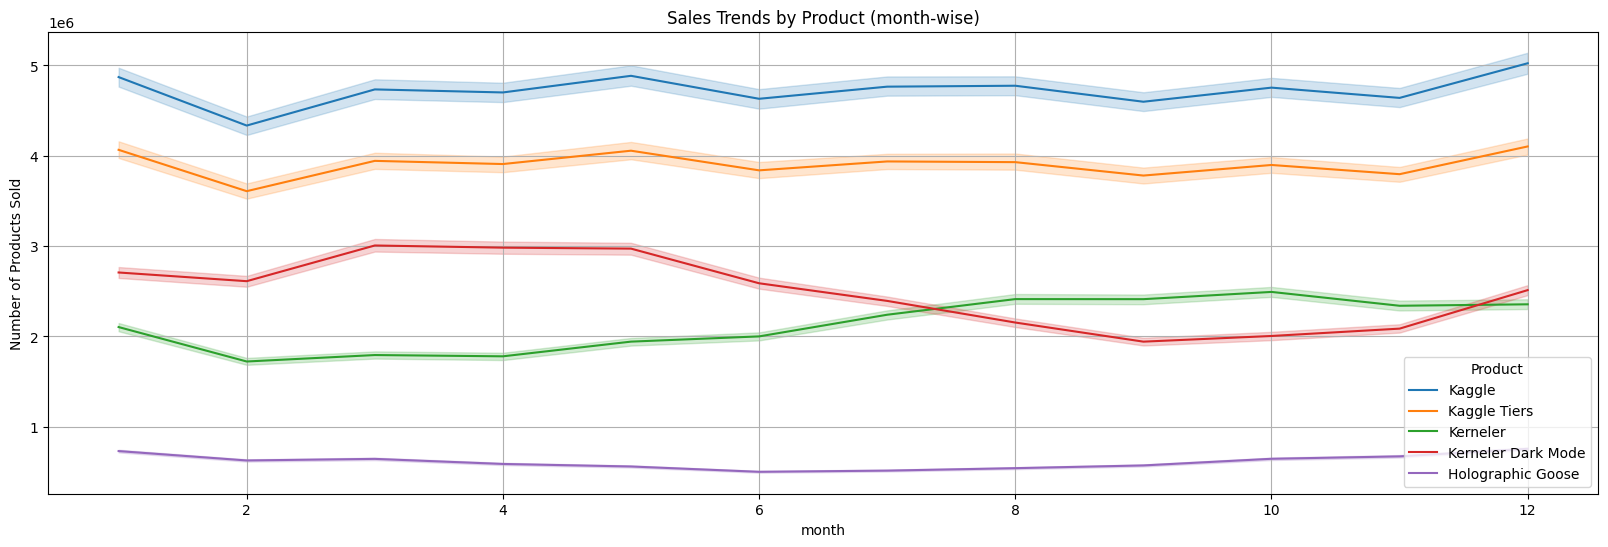

CPU times: total: 2.47 s
Wall time: 2.64 s


In [92]:
%%time
# 3. Sales trends by product (month-wise)
train['date'] = pd.to_datetime(train['date'])  # Convert 'date' column to datetime format
train['month'] = train['date'].dt.month  # Extract year from the date column

plt.figure(figsize=(20, 6))
sns.lineplot(data=train, x='month', y='num_sold', hue='product', estimator='sum')
plt.title('Sales Trends by Product (month-wise)')
plt.xlabel('month')
plt.ylabel('Number of Products Sold')
plt.legend(title='Product')
plt.grid()
plt.show()


<div style="border: 5px solid #2e3b4e; border-radius: 35px; padding: 20px; font-family: Arial, sans-serif; line-height: 1.6; background-color: white; color: #2e3b4e;">
  <h2>Store-Level Sales Trends</h2>
  <p>This line plot shows the sales performance of products over time, broken down by store. Each line represents total sales for a specific store on each date. The x-axis shows the date, and the y-axis shows the number of products sold. This visualization highlights individual store sales trends and allows for comparative analysis of store performance.</p>
</div>


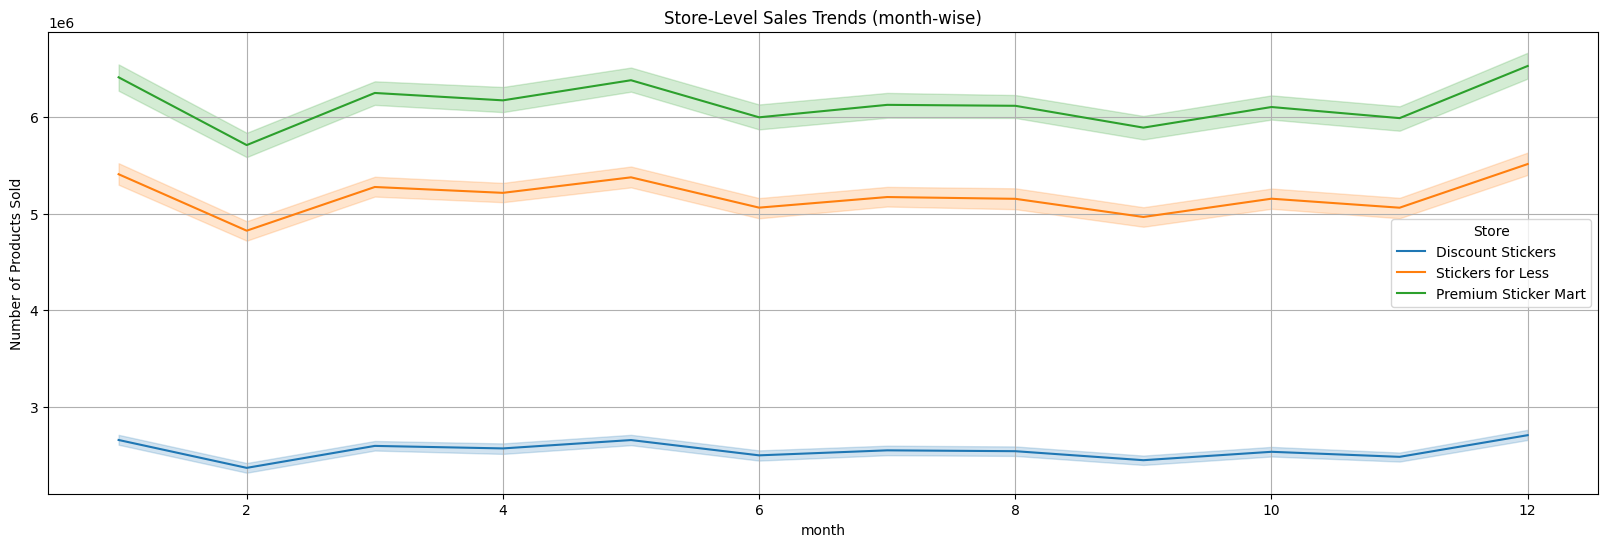

CPU times: total: 2.42 s
Wall time: 2.6 s


In [93]:
%%time
# 4. Store-level trends (month-wise)
train['date'] = pd.to_datetime(train['date'], errors='coerce')  # Ensure 'date' is datetime type
train['month'] = train['date'].dt.month  # Extract year from the date column

plt.figure(figsize=(20, 6))
sns.lineplot(data=train, x='month', y='num_sold', hue='store', estimator='sum')
plt.title('Store-Level Sales Trends (month-wise)')
plt.xlabel('month')
plt.ylabel('Number of Products Sold')
plt.legend(title='Store')
plt.grid()
plt.show()


<div style="border: 5px solid #2e3b4e; border-radius: 35px; padding: 20px; font-family: Arial, sans-serif; line-height: 1.6; background-color: white; color: #2e3b4e;">
  <h2>Sales Trends Aggregated by Week and Month</h2>
  <p>This process aggregates the number of products sold by week and month, then visualizes the results with a line plot.</p>

  <h3>Steps Taken:</h3>
  <ul>
    <li><strong>Weekly Aggregation:</strong> Grouped sales data by week and summed the products sold for each week.</li>
    <li><strong>Monthly Aggregation:</strong> Grouped sales data by month and summed the products sold for each month.</li>
    <li><strong>Visualization:</strong> Created a line plot using the monthly aggregated data to show sales trends over time.</li>
  </ul>

  <h3>Visualization:</h3>
  <p>The following line plot shows sales trends aggregated by month:</p>
  <img src="path_to_your_generated_plot.png" alt="Sales Trends by Month" style="max-width: 100%; height: auto;">
</div>


In [94]:
weekly_df = train.groupby([pd.Grouper(key="date", freq="W")])["num_sold"].sum().rename("num_sold").reset_index()
monthly_df = train.groupby([pd.Grouper(key="date", freq="MS")])["num_sold"].sum().rename("num_sold").reset_index()


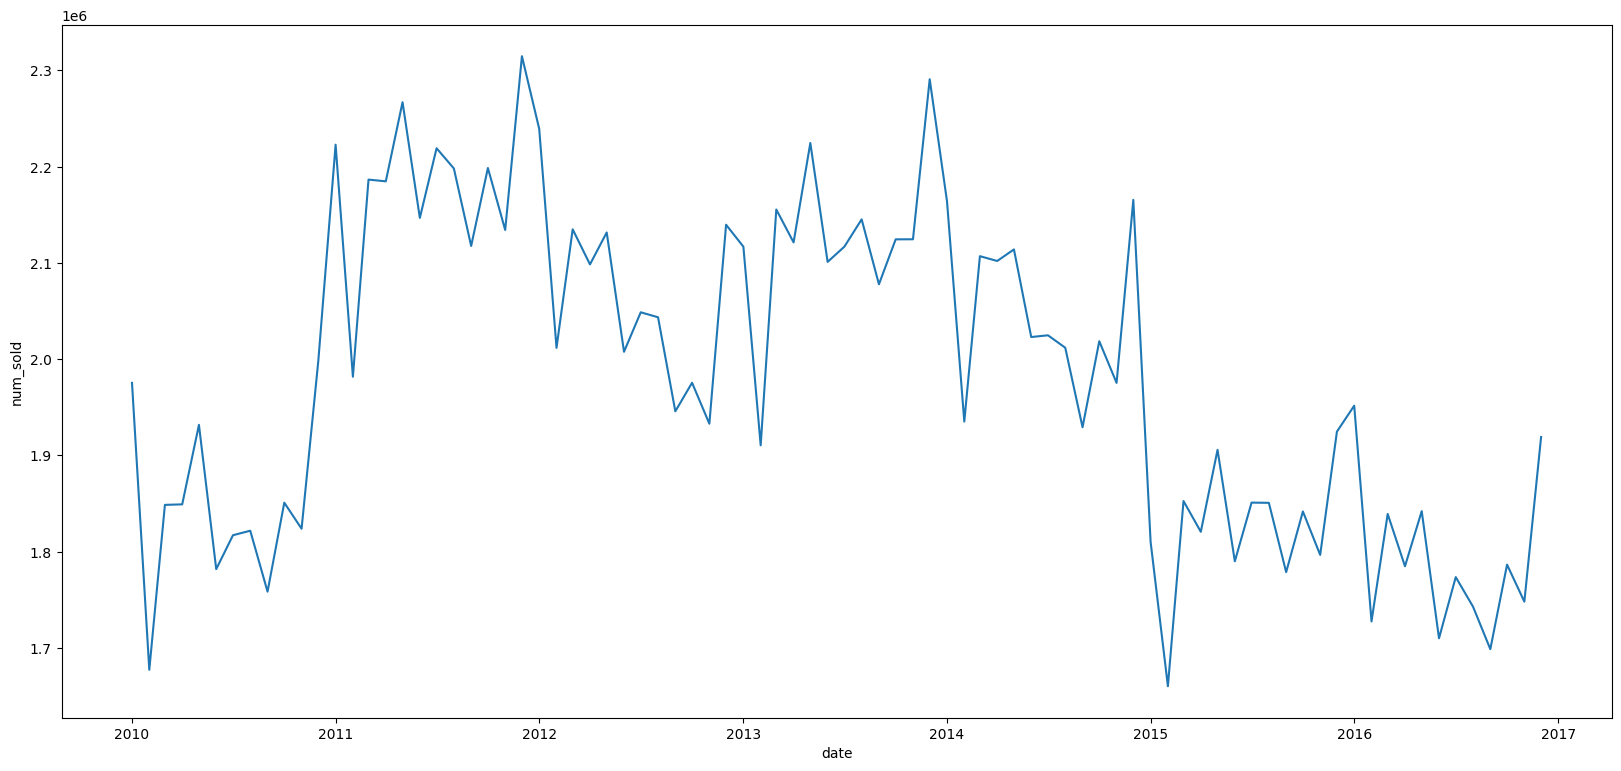

In [95]:
f,ax = plt.subplots(figsize=(20,9))
sns.lineplot(data=monthly_df, x="date", y="num_sold");

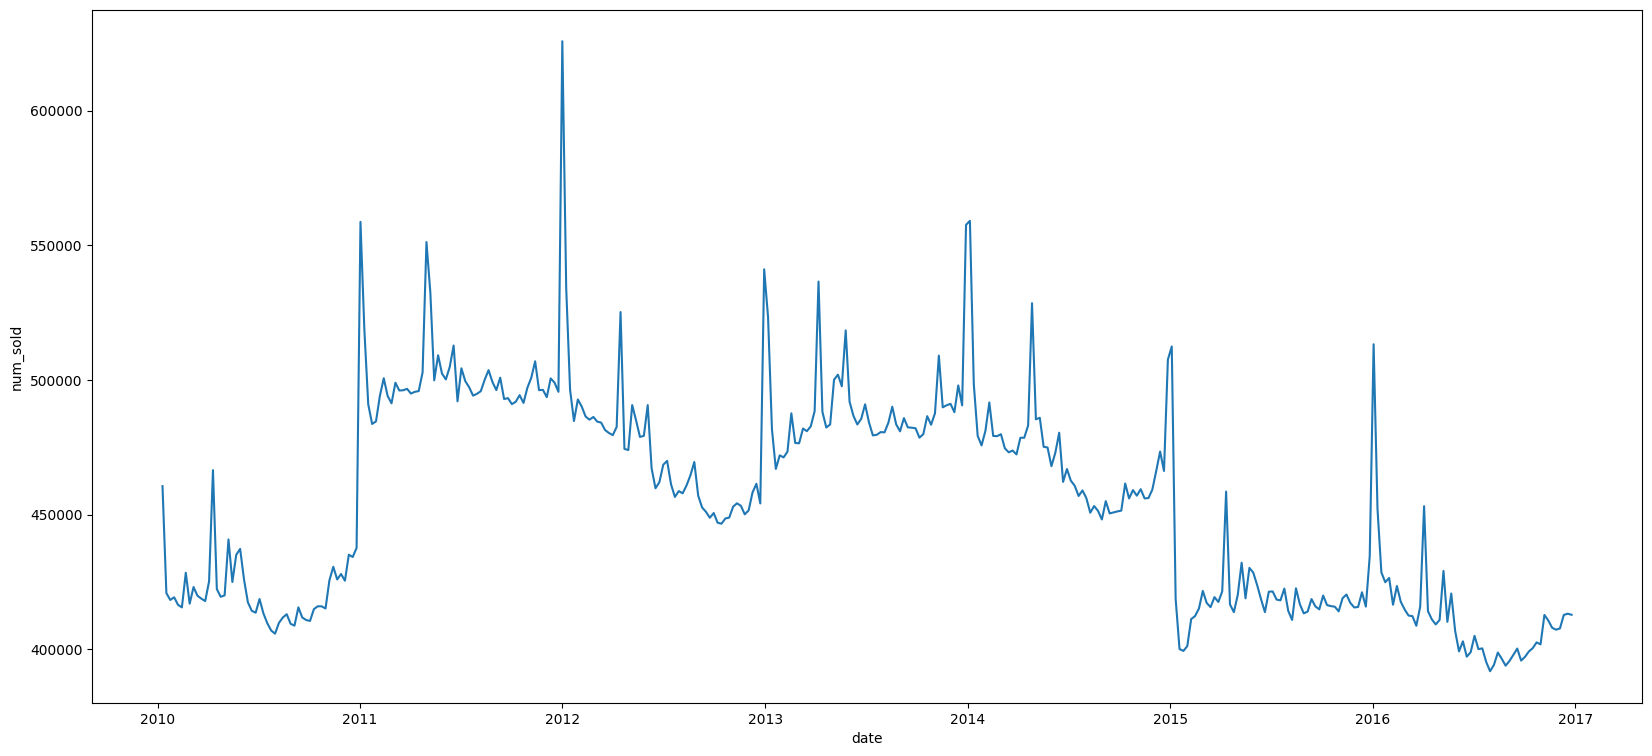

In [96]:
f,ax = plt.subplots(figsize=(20,9))
sns.lineplot(data=weekly_df[1:-1], x="date", y="num_sold");

<div style="border: 5px solid #2e3b4e; border-radius: 35px; padding: 20px; font-family: Arial, sans-serif; line-height: 1.6; background-color: white; color: #2e3b4e;">
  <h2>Seasonal Component Plot</h2>
  <p>The <strong>Seasonal Component Plot</strong> is a visualization that shows the repeating patterns or cycles in time series data, often corresponding to seasonal effects like yearly, monthly, or weekly fluctuations. It helps to identify periodic behaviors, which can be critical for understanding and forecasting time-based data such as sales, weather, or website traffic.</p>


 
  </pre>
</div>


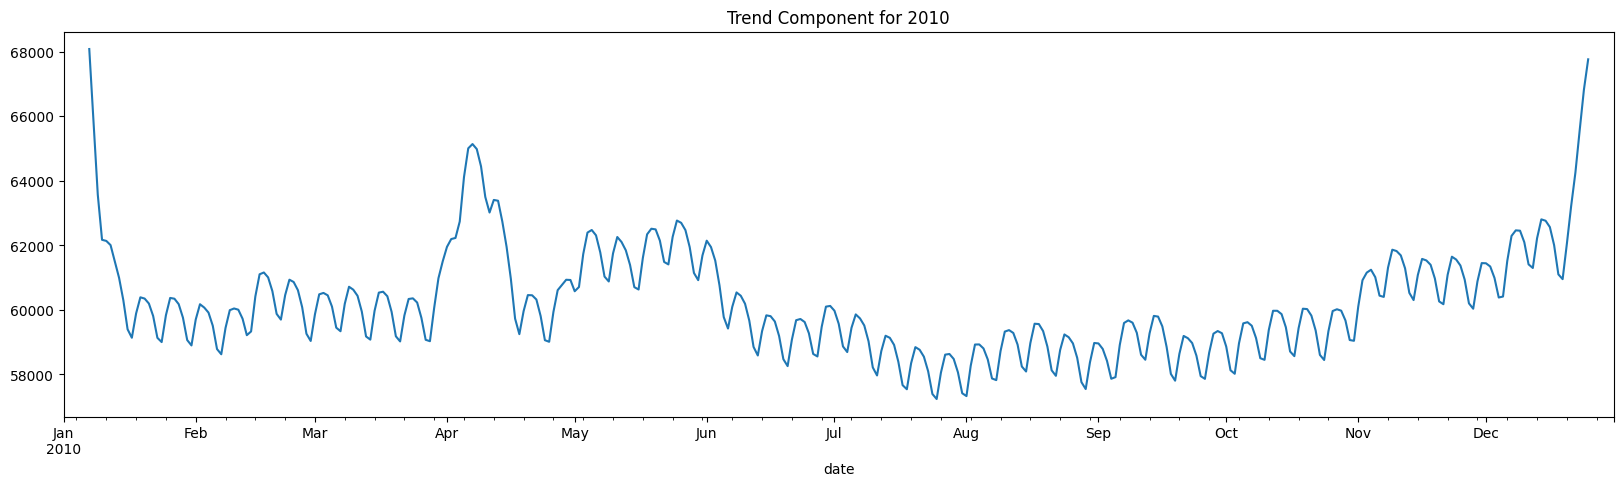

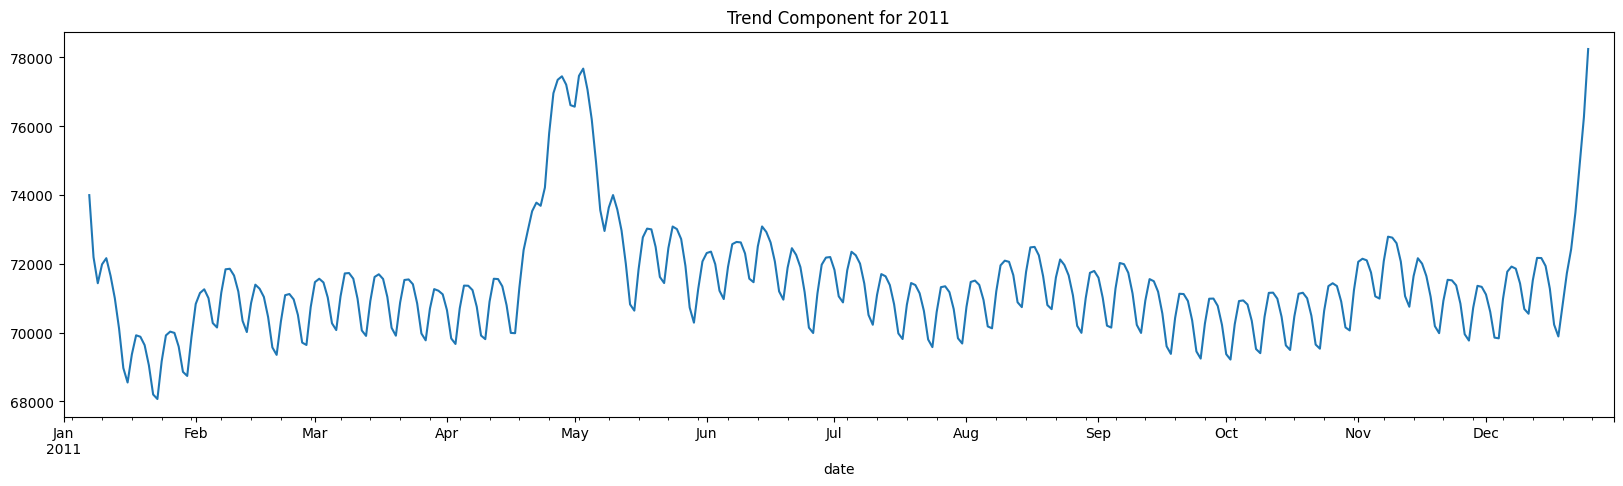

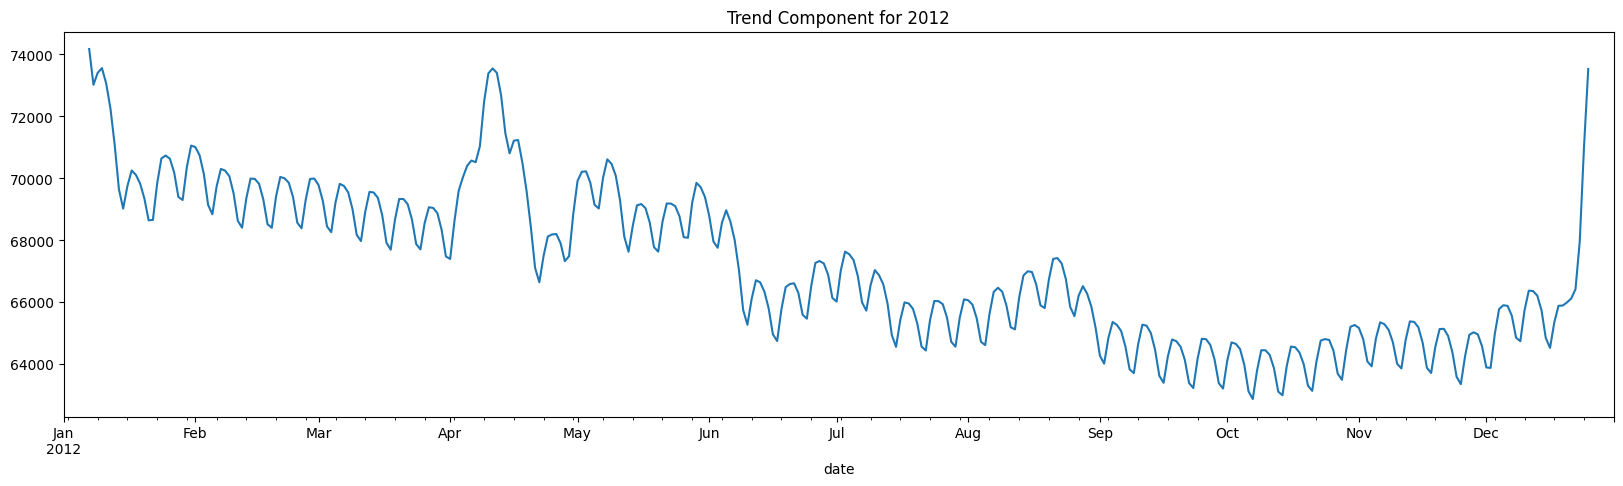

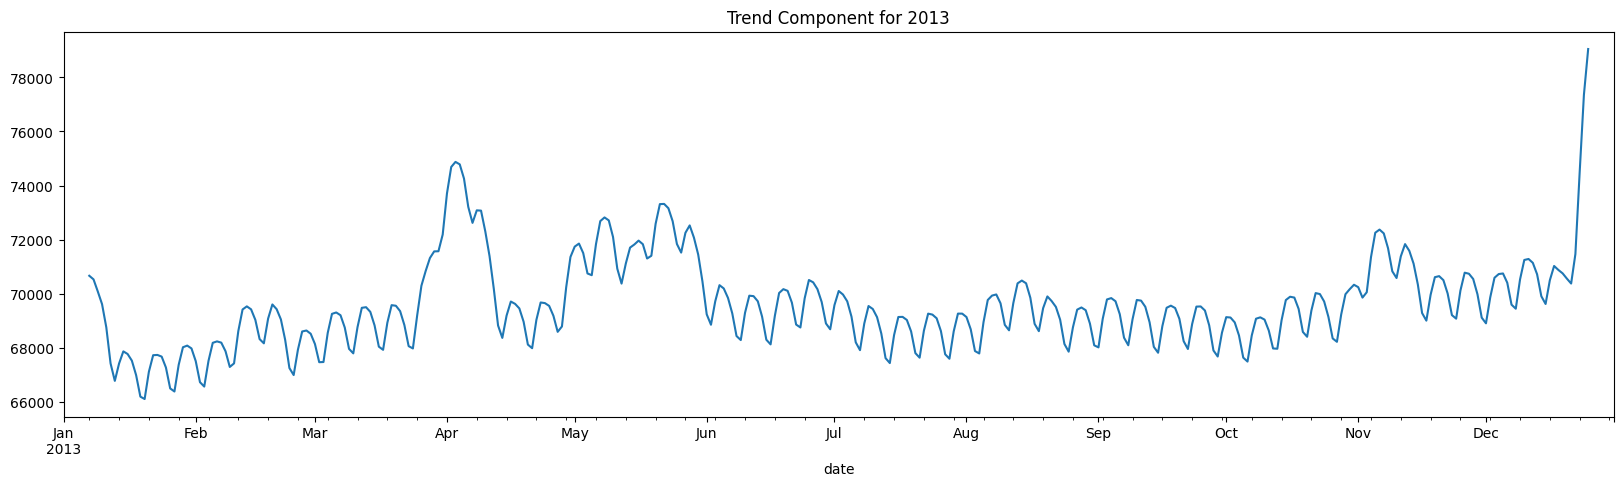

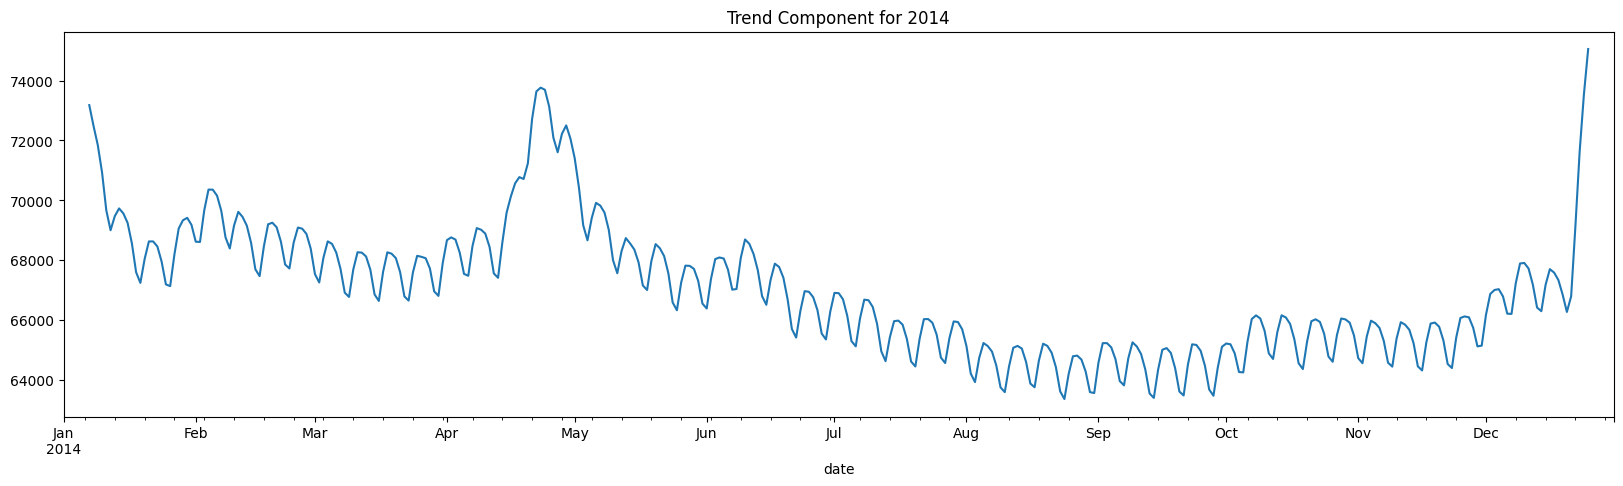

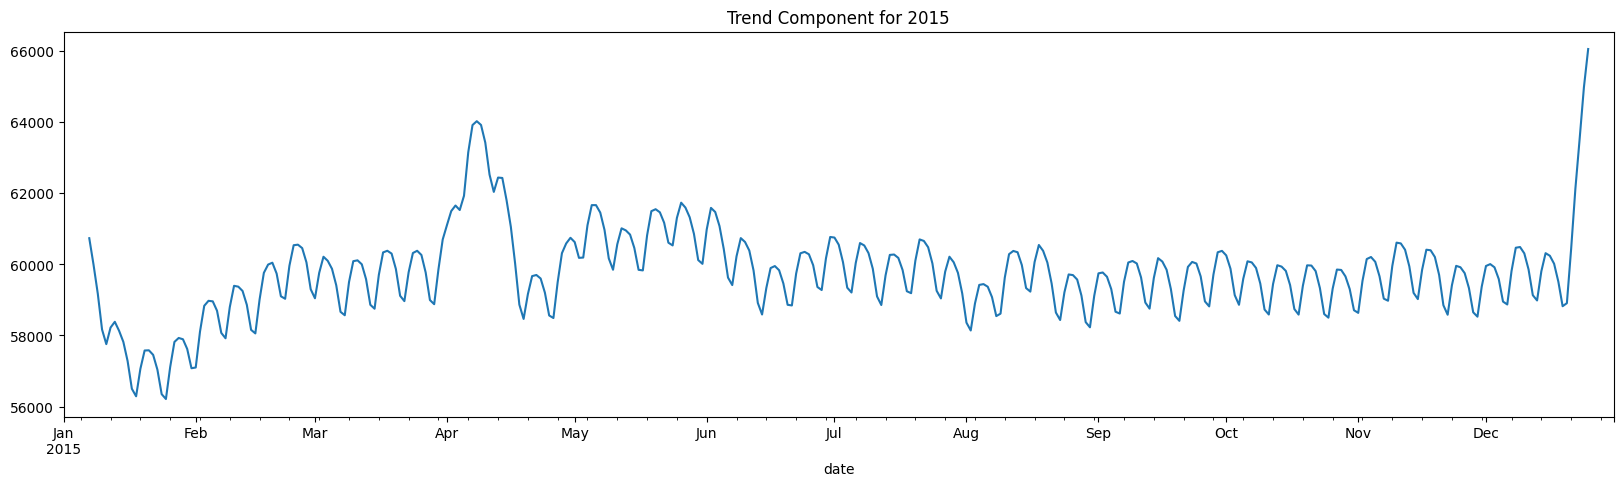

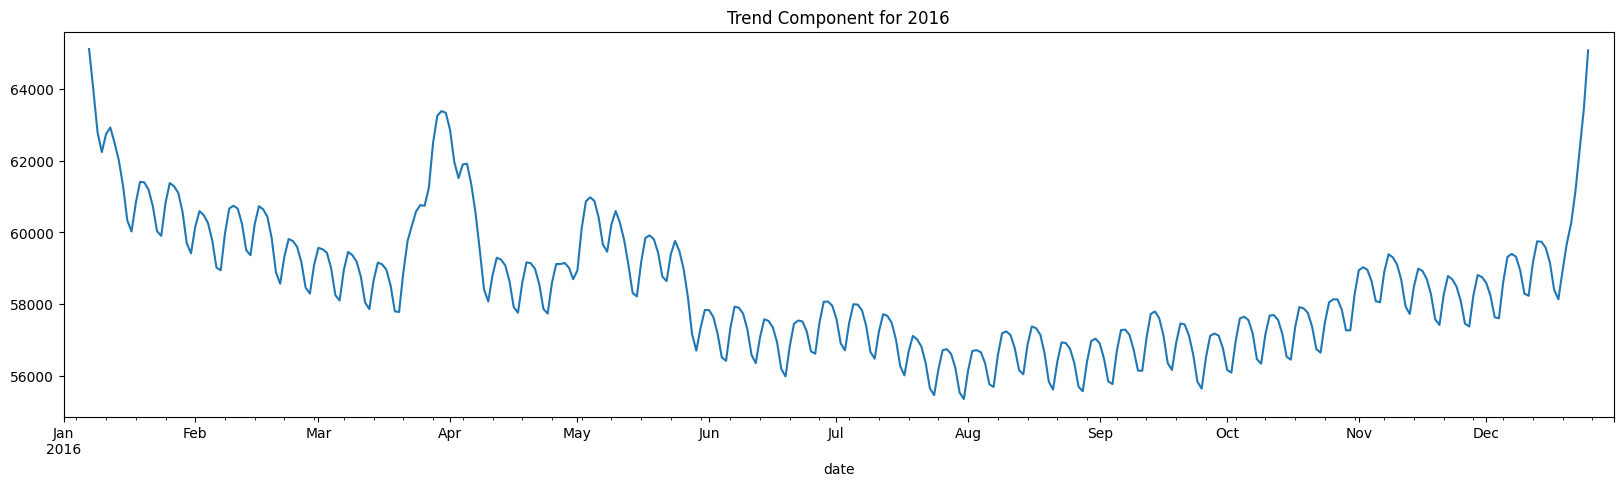

In [97]:
X_data_index = train.set_index('date')
from statsmodels.tsa.seasonal import seasonal_decompose

monthly_data = X_data_index.resample('D').sum()

monthly_data['year'] = monthly_data.index.year
monthly_data['month'] = monthly_data.index.month

for year in monthly_data['year'].unique():
    yearly_data = monthly_data[monthly_data['year'] == year]
    
    decomposition = seasonal_decompose(yearly_data['num_sold'], model='additive', period=12)
    
    plt.figure(figsize=(20, 5))
    decomposition.trend.plot()
    plt.title(f'Trend Component for {year}')
    plt.show()

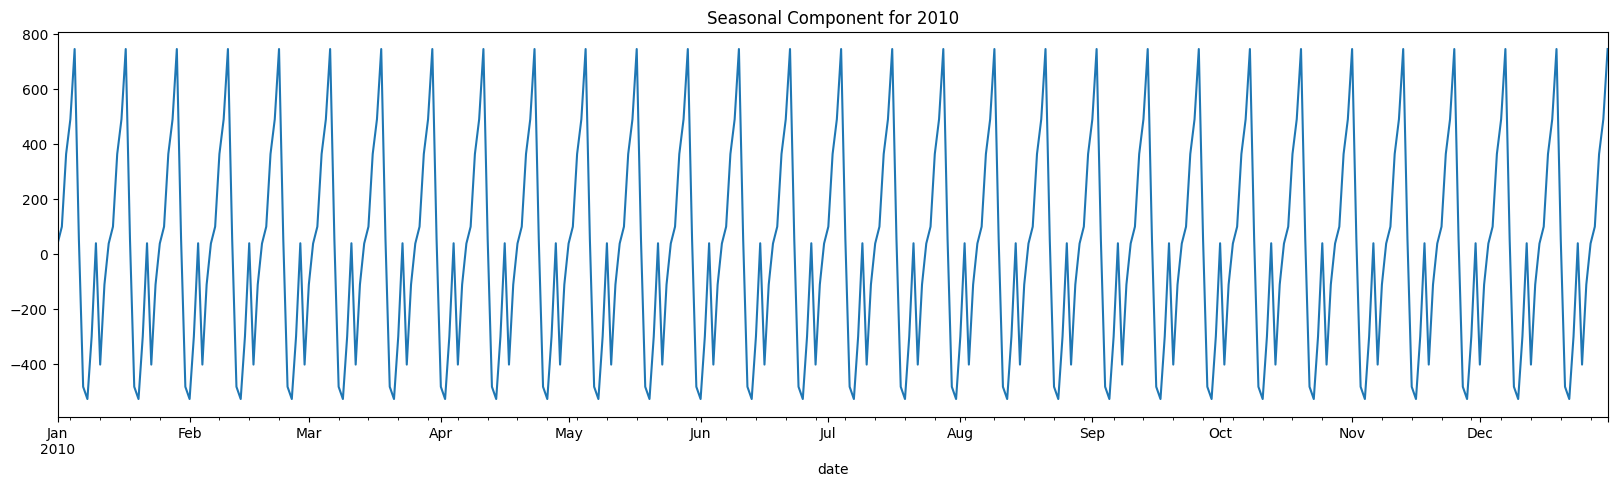

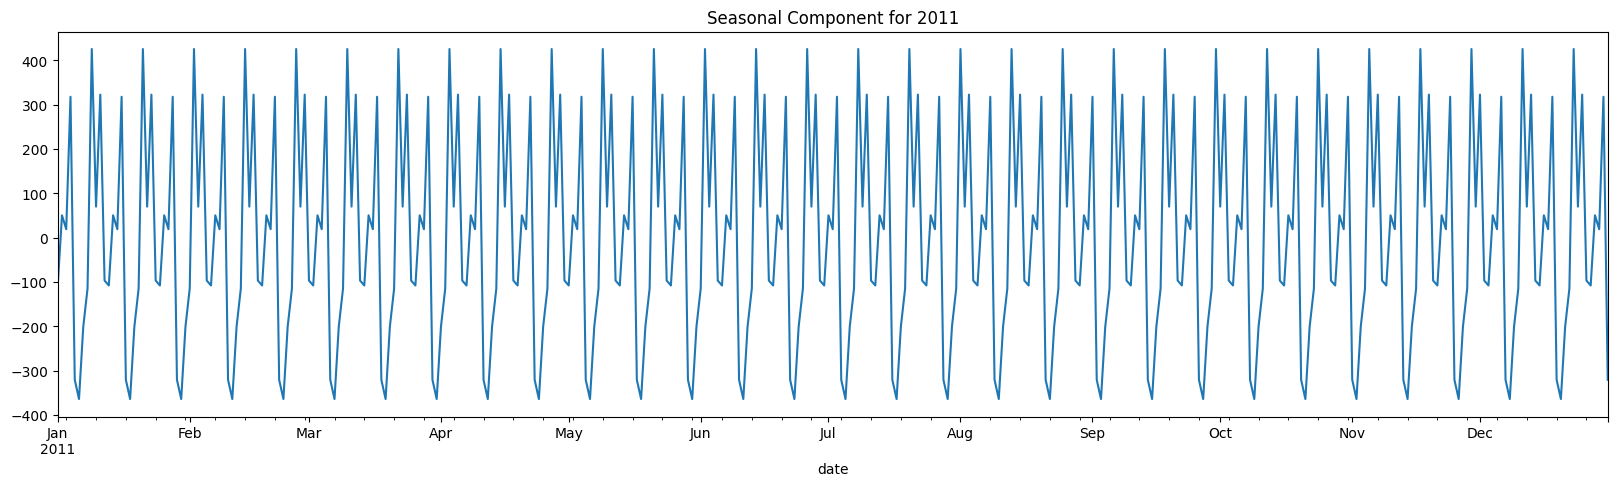

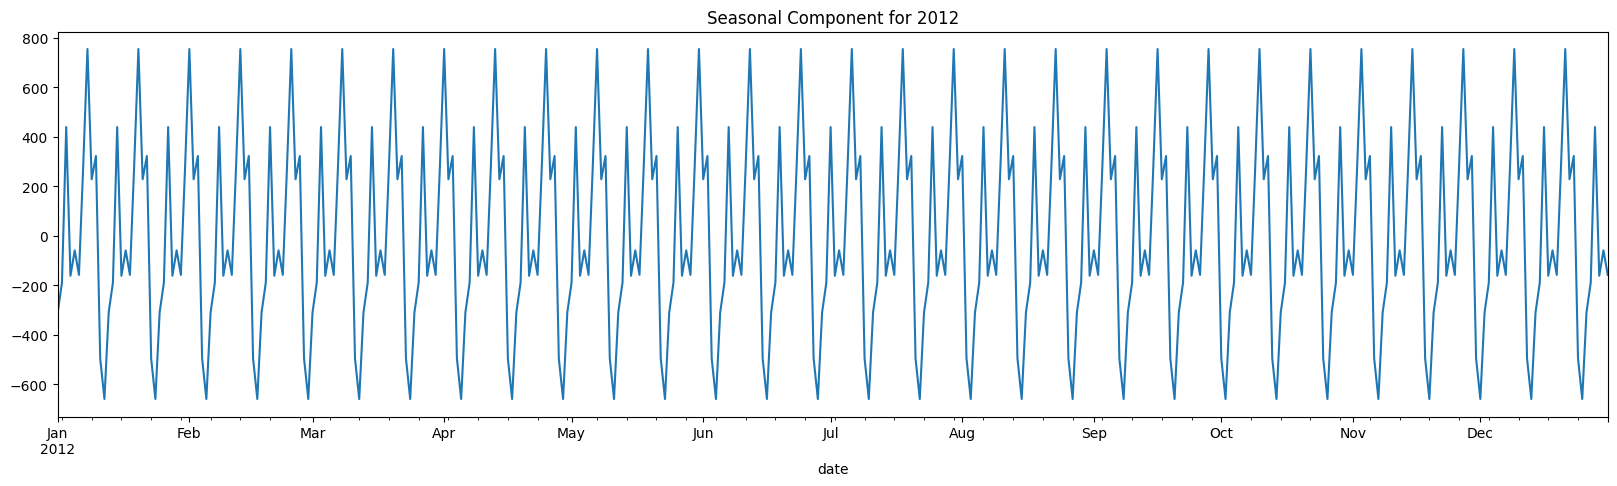

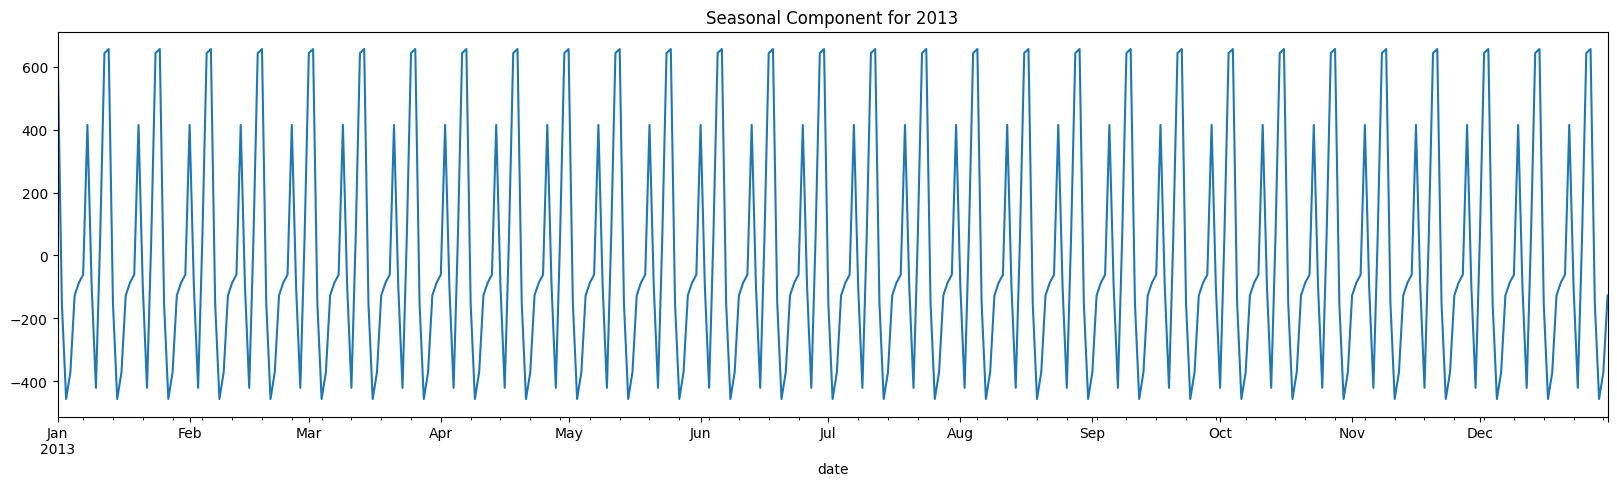

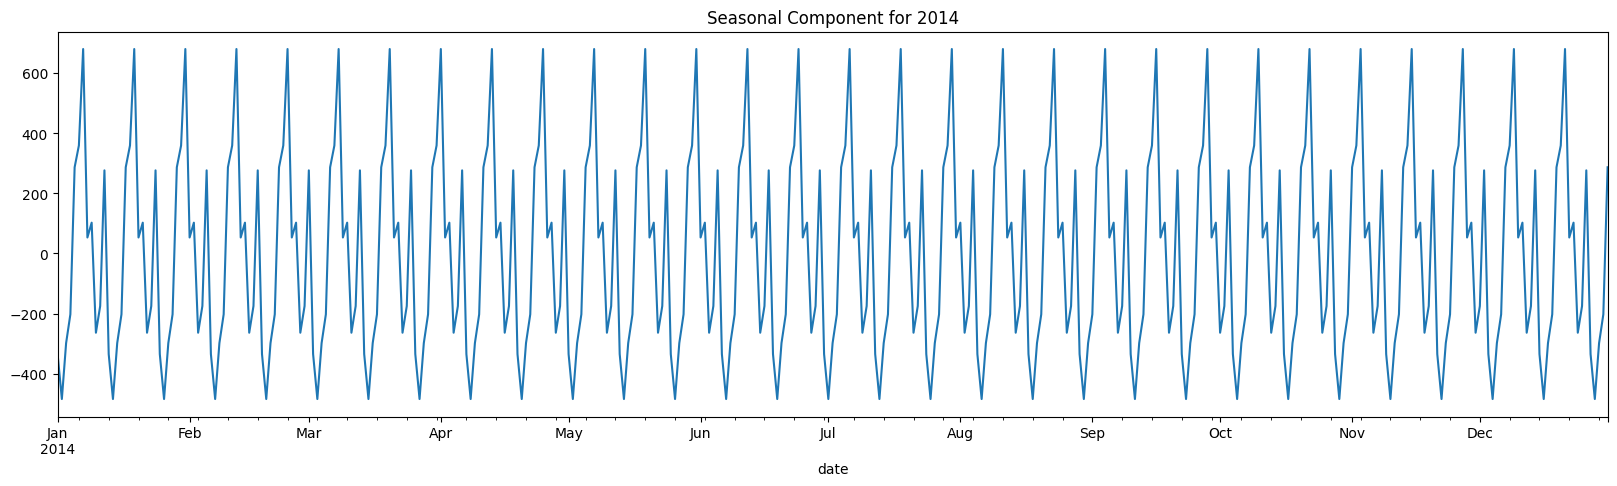

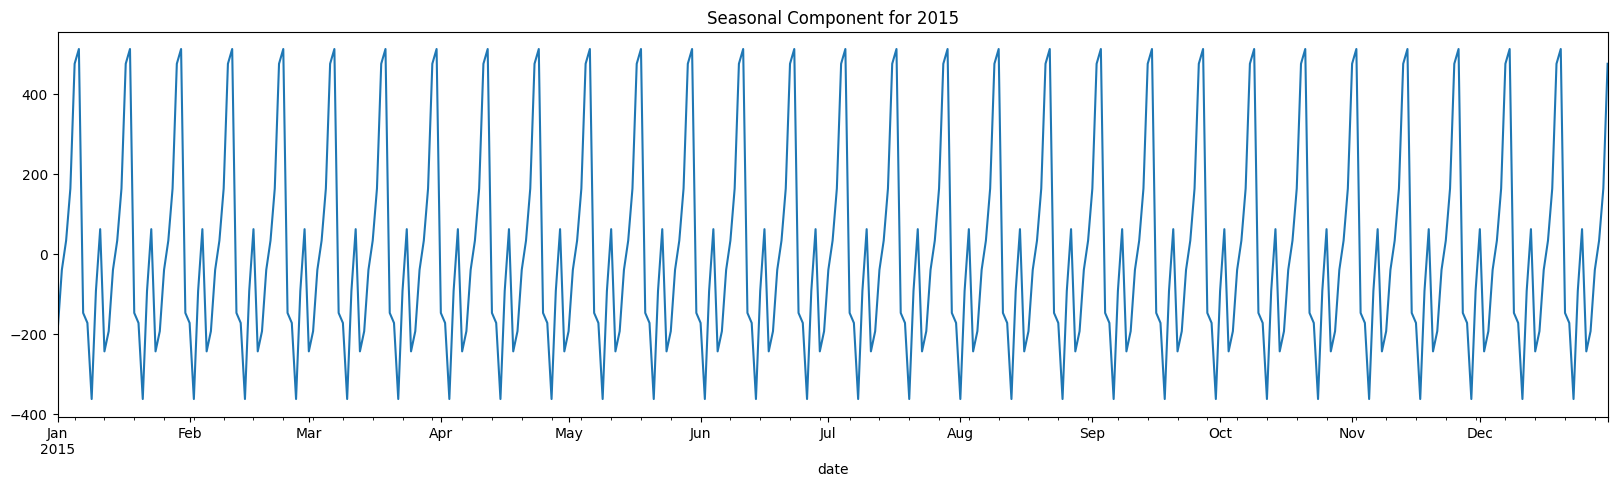

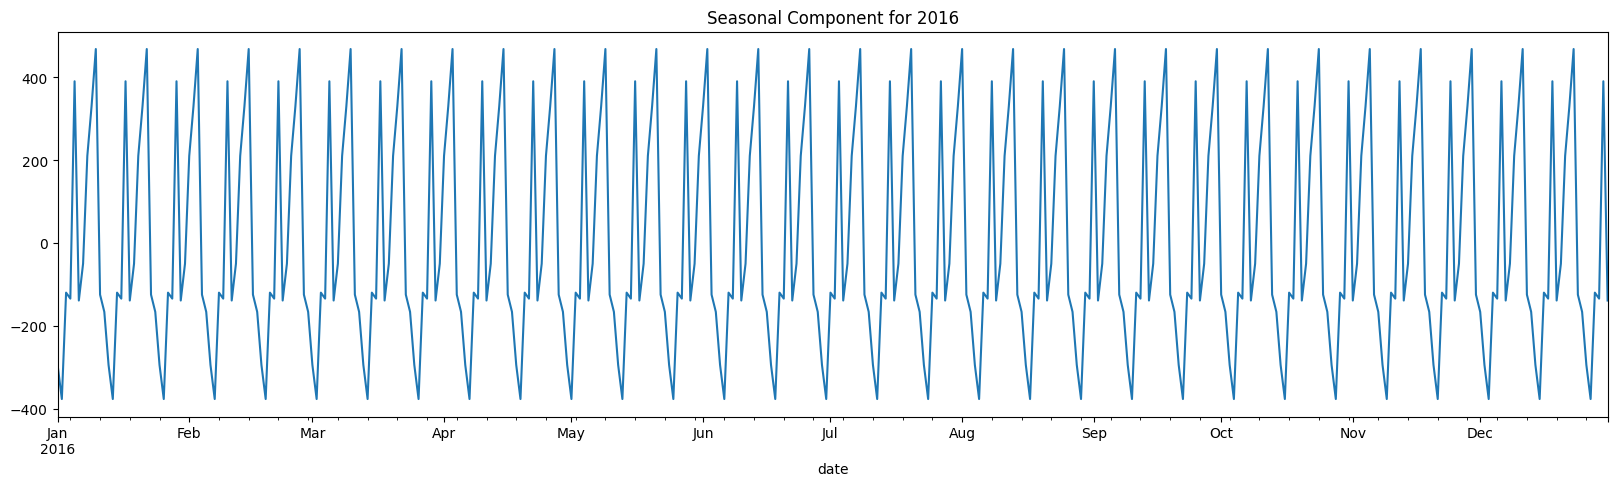

In [98]:
for year in monthly_data['year'].unique():
    yearly_data = monthly_data[monthly_data['year'] == year]
    
    decomposition = seasonal_decompose(yearly_data['num_sold'], model='additive', period=12)

    plt.figure(figsize=(20, 5))
    decomposition.seasonal.plot()
    plt.title(f'Seasonal Component for {year}')
    plt.show()

<div style="border: 5px solid #2e3b4e; border-radius: 35px; padding: 20px; font-family: Arial, sans-serif; line-height: 1.6; background-color: white; color: #2e3b4e;">
  <h2>Autocorrelation (ACF) Plot</h2>
  <p>This plot visualizes the correlation of the time series with its lagged values. The x-axis represents the lag (in days), and the y-axis shows the correlation coefficient. Significant spikes indicate strong correlations at specific lags, which may reveal seasonality, trends, or repeating patterns in the data. This analysis helps in understanding time series dependencies and preparing for forecasting models.</p>
</div>


<Figure size 1000x600 with 0 Axes>

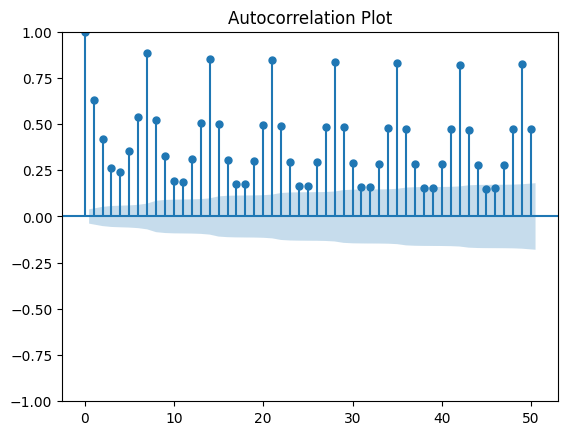

In [99]:
# 5. Autocorrelation (ACF) Plot

from statsmodels.graphics.tsaplots import plot_acf

# Aggregate data by day to create the time series
trend_data = train.groupby('date')['num_sold'].sum()

plt.figure(figsize=(10, 6))
plot_acf(trend_data.dropna(), lags=50)
plt.title('Autocorrelation Plot')
plt.show()



<a id="dataset-analysis"></a>
<p style="padding:30px;background-color:#2e3b4e;margin:0;color:#e8e8e8;font-family:Arial,sans-serif;font-size:250%;text-align:center;border-radius:10px;overflow:hidden;font-weight:800">
    🚀 Data Preprocessing 🚀

<div style="border: 5px solid #2e3b4e; border-radius: 35px; padding: 20px; font-family: Arial, sans-serif; line-height: 1.6; background-color: white; color: #2e3b4e;">
  <h2>Train Data and Test Data</h2>
  <p>The following tables represent the transformed versions of the train_data and test_data, where the original 'date' column has been split into Year, Month, and Day. Additionally, cyclical encodings have been added for Day, Month, and Year to capture seasonality and periodicity.</p>
  
  <h3>Cyclical Encodings Formula</h3>
  <p>To capture the cyclical nature of time-related features like Day, Month, and Year, the following sine and cosine transformations are used:</p>
  <ul>
    <li><strong>Day Sin</strong>: <code>sin(2 * π * Day / 365.0)</code></li>
    <li><strong>Day Cos</strong>: <code>cos(2 * π * Day / 365.0)</code></li>
    <li><strong>Month Sin</strong>: <code>sin(2 * π * Month / 12.0)</code></li>
    <li><strong>Month Cos</strong>: <code>cos(2 * π * Month / 12.0)</code></li>
    <li><strong>Year Sin</strong>: <code>sin(2 * π * Year / 7.0)</code></li>
    <li><strong>Year Cos</strong>: <code>cos(2 * π * Year / 7.0)</code></li>
  </ul>
  
  <h3>Train Data</h3>
  <table border="1" style="width: 100%; margin-bottom: 20px;">
    <thead>
      <tr>
        <th>Year</th>
        <th>Quarter</th>
        <th>Month</th>
        <th>Day</th>
        <th>Day of Week</th>
        <th>Week of Year</th>
        <th>Hour</th>
        <th>Minute</th>
        <th>Day Sin</th>
        <th>Day Cos</th>
        <th>Month Sin</th>
        <th>Month Cos</th>
        <th>Year Sin</th>
        <th>Year Cos</th>
        <th>Group</th>
      </tr>
    </thead>
    <tbody>
      <tr>
        <td>2025</td>
        <td>1</td>
        <td>1</td>
        <td>1</td>
        <td>3</td>
        <td>1</td>
        <td>10</td>
        <td>30</td>
        <td>0.0092</td>
        <td>0.9999</td>
        <td>0.5236</td>
        <td>0.8525</td>
        <td>0.1419</td>
        <td>0.9899</td>
        <td>90</td>
      </tr>
    </tbody>
  </table>

  <h3>Test Data</h3>
  <table border="1" style="width: 100%;">
    <thead>
      <tr>
        <th>Year</th>
        <th>Quarter</th>
        <th>Month</th>
        <th>Day</th>
        <th>Day of Week</th>
        <th>Week of Year</th>
        <th>Hour</th>
        <th>Minute</th>
        <th>Day Sin</th>
        <th>Day Cos</th>
        <th>Month Sin</th>
        <th>Month Cos</th>
        <th>Year Sin</th>
        <th>Year Cos</th>
        <th>Group</th>
      </tr>
    </thead>
    <tbody>
      <tr>
        <td>2025</td>
        <td>1</td>
        <td>1</td>
        <td>1</td>
        <td>3</td>
        <td>1</td>
        <td>10</td>
        <td>30</td>
        <td>0.0092</td>
        <td>0.9999</td>
        <td>0.5236</td>
        <td>0.8525</td>
        <td>0.1419</td>
        <td>0.9899</td>
        <td>90</td>
      </tr>
    </tbody>
  </table>
</div>


In [100]:
def transform_date(df, col):
    # Convert the column to datetime
    df[col] = pd.to_datetime(df[col])
                             
    # Extract temporal features
    df[f'{col}_year'] = df[col].dt.year.astype('float64')
    df[f'{col}_quarter'] = df[col].dt.quarter.astype('float64')
    df[f'{col}_month'] = df[col].dt.month.astype('float64')
    df[f'{col}_day'] = df[col].dt.day.astype('float64')
    df[f'{col}_day_of_week'] = df[col].dt.dayofweek.astype('float64')
    df[f'{col}_week_of_year'] = df[col].dt.isocalendar().week.astype('float64')
    df[f'{col}_hour'] = df[col].dt.hour.astype('float64')
    df[f'{col}_minute'] = df[col].dt.minute.astype('float64')
    
    # Add cyclical encodings
    df[f'{col}_day_sin'] = np.sin(2 * np.pi * df[f'{col}_day'] / 365.0)
    df[f'{col}_day_cos'] = np.cos(2 * np.pi * df[f'{col}_day'] / 365.0)
    df[f'{col}_month_sin'] = np.sin(2 * np.pi * df[f'{col}_month'] / 12.0)
    df[f'{col}_month_cos'] = np.cos(2 * np.pi * df[f'{col}_month'] / 12.0)
    df[f'{col}_year_sin'] = np.sin(2 * np.pi * df[f'{col}_year'] / 7.0)
    df[f'{col}_year_cos'] = np.cos(2 * np.pi * df[f'{col}_year'] / 7.0)
    
    # Add group feature (for time-based grouping)
    df[f'{col}_Group'] = (df[f'{col}_year'] - 2010) * 48 + df[f'{col}_month'] * 4 + df[f'{col}_day'] // 7

    return df


In [101]:
new_train = transform_date(train, 'date')
new_test = transform_date(test, 'date')

In [102]:
new_train['num_sold'] = np.log1p(new_train['num_sold'])
new_train = new_train.drop(columns=['date', 'id'], axis=1)
new_test = new_test.drop(columns=['date', 'id'], axis=1)


<div style="border: 5px solid #2e3b4e; border-radius: 35px; padding: 20px; font-family: Arial, sans-serif; line-height: 1.6; background-color: white; color: #2e3b4e;">
  <h2>Data Preprocessing</h2>
  <p>In this section, the 'id' column has been dropped from the train_data, and the numeric and categorical columns have been identified for both the train and test datasets. The 'num_sold' column is excluded from the numeric columns for train_data.</p>

  <h3>Train Data Columns</h3>
  <p><strong>Numeric Columns:</strong> num_cols = [list of numeric columns excluding 'num_sold']</p>
  <p><strong>Categorical Columns:</strong> cat_cols = [list of categorical columns]</p>

  <h3>Test Data Columns</h3>
  <p><strong>Numeric Columns:</strong> num_cols_test = [list of numeric columns excluding 'id']</p>
  <p><strong>Categorical Columns:</strong> cat_cols_test = [list of categorical columns]</p>
</div>


In [103]:

num_cols = list(new_train.select_dtypes(exclude=['object']).columns.difference(['num_sold']))
cat_ftrs = list(new_train.select_dtypes(include=['object']).columns)

num_cols_test = list(new_test.select_dtypes(exclude=['object']).columns.difference(['id']))
cat_ftrs_test = list(new_test.select_dtypes(include=['object']).columns)

<div style="border: 5px solid #2e3b4e; border-radius: 35px; padding: 20px; font-family: Arial, sans-serif; line-height: 1.6; background-color: white; color: #2e3b4e;">
  <h2>Feature Preprocessing</h2>
  <p>Performed preprocessing to encode categorical features, optimize numerical data types, and ensure consistent formatting across train and test datasets.</p>
  
  <h3>Steps Taken:</h3>
  <ul>
    <li><strong>Categorical Features:</strong> Applied factorization to convert each unique category into an integer, adjusted values to start at 0, and optimized by converting to <code>category</code> type.</li>
    <li><strong>Numerical Features:</strong> Converted <code>float64</code> to <code>float32</code> and <code>int64</code> to <code>int32</code> for memory efficiency.</li>
    <li><strong>Data Consolidation:</strong> Combined train and test data for consistent preprocessing, then split back into respective datasets.</li>
  </ul>
</div>


In [104]:
train_test_comb = pd.concat([new_train, new_test], axis=0, ignore_index=True)
for col in cat_ftrs:
    train_test_comb[col], _ = train_test_comb[col].factorize()
    train_test_comb[col] -= train_test_comb[col].min()
    # label encode to categorical and convert int32 to category
    train_test_comb[col] = train_test_comb[col].astype('int32')
    train_test_comb[col] = train_test_comb[col].astype('category')

for col in num_cols:
    if train_test_comb[col].dtype=='float64':
        train_test_comb[col].astype('float32')
    if train_test_comb[col].dtype=='int64':
        train_test_comb[col].astype('int32')

new_train = train_test_comb.iloc[:len(new_train)].copy()
new_test = train_test_comb.iloc[len(new_train):].copy()


In [105]:
new_test = new_test.drop(columns='num_sold', axis=1)

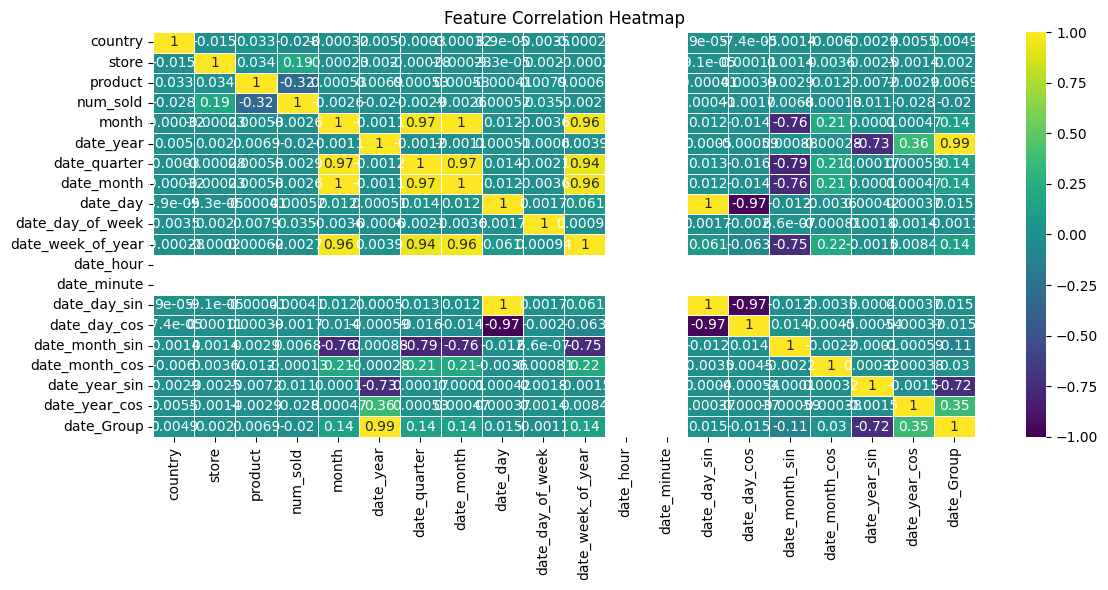

In [106]:
# Calculate the correlation matrix
correlation_matrix = new_train.corr()

# Plot the heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='viridis', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()


<a id="dataset-analysis"></a>
<p style="padding:30px;background-color:#2e3b4e;margin:0;color:#e8e8e8;font-family:Arial,sans-serif;font-size:250%;text-align:center;border-radius:10px;overflow:hidden;font-weight:800">
    🚀 Model Building 🚀

In [107]:
X= new_train.drop(columns=['num_sold'])
y = new_train['num_sold']

<div style="border: 5px solid #2e3b4e; border-radius: 35px; padding: 20px; font-family: Arial, sans-serif; line-height: 1.6; background-color: white; color: #2e3b4e;">
  <h2>Hyperparameter Optimization with Optuna for LightGBM</h2>
  <p>This process involves using the <strong>Optuna</strong> library to optimize the hyperparameters of a <strong>LGBMRegressor</strong> (LightGBM) model. The goal is to find the best set of hyperparameters that minimize the Mean Absolute Percentage Error (MAPE) on the validation dataset.</p>

  <h3>Steps Taken:</h3>
  <ul>
    <li><strong>Define Objective Function:</strong> Optimizes LightGBM hyperparameters using Optuna.</li>
    <li><strong>Hyperparameters:</strong> Key hyperparameters include:
      <ul>
        <li><code>n_estimators</code>: Number of boosting rounds (100-1000)</li>
        <li><code>learning_rate</code>: Learning rate (0.01 - 0.3)</li>
        <li><code>max_depth</code>: Maximum depth of trees (5-15)</li>
        <li><code>reg_alpha</code>: L1 regularization (1e-4 - 1.0)</li>
        <li><code>lambda_l2</code>: L2 regularization (1e-4 - 1.0)</li>
        <li><code>min_child_samples</code>: Minimum number of samples per leaf (20-100)</li>
        <li><code>colsample_bytree</code>: Fraction of features used in each tree (0.6 - 1.0)</li>
        <li><code>subsample</code>: Fraction of samples used for training (0.5 - 1.0)</li>
      </ul>
    </li>
    <li><strong>Data Splitting:</strong> Split the dataset into training and validation sets.</li>
    <li><strong>Model Training:</strong> Train the LightGBM model on the training set and evaluate on the validation set.</li>
    <li><strong>Optimization:</strong> Run Optuna optimization with 50 trials to minimize MAPE.</li>
    <li><strong>Best Parameters:</strong> Extract the best hyperparameters after optimization.</li>
  </ul>
</div>


In [108]:
import lightgbm as lgb
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

def objective(trial):
    params = {
        'boosting_type': 'gbdt',
        'objective': 'regression',
        'metric': 'mape',  # We'll evaluate on MAPE
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.3),
        'max_depth': trial.suggest_int('max_depth', 5, 15),
        'reg_alpha': trial.suggest_loguniform('reg_alpha', 1e-4, 1.0),
        'lambda_l2': trial.suggest_loguniform('lambda_l2', 1e-4, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 100),
        'colsample_bytree': trial.suggest_uniform('colsample_bytree', 0.6, 1.0),
        'subsample': trial.suggest_uniform('subsample', 0.5, 1.0),
        'random_state': 42,
        'verbose': -1,
        'device': 'cpu'
    }
    
    model = lgb.LGBMRegressor(**params)
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)])
    
    y_pred = model.predict(X_val)
    mape = mean_absolute_percentage_error(y_val, y_pred)
    return mape

# Run Optuna optimization
study = optuna.create_study(direction='minimize')
optuna.logging.set_verbosity(optuna.logging.WARNING)
study.optimize(objective, n_trials=100,show_progress_bar=True)

# Best parameters and MAPE
print("Best parameters:", study.best_params)
print("Best MAPE:", study.best_value)

  0%|          | 0/100 [00:00<?, ?it/s]

Best parameters: {'n_estimators': 994, 'learning_rate': 0.1254262922656379, 'max_depth': 13, 'reg_alpha': 0.0003234094745066539, 'lambda_l2': 0.04583251517730864, 'min_child_samples': 27, 'colsample_bytree': 0.7234157908528648, 'subsample': 0.6419600509470709}
Best MAPE: 0.007897542029798041


<div style="border: 5px solid #2e3b4e; border-radius: 35px; padding: 20px; font-family: Arial, sans-serif; line-height: 1.6; background-color: white; color: #2e3b4e;">
  <h2>K-Fold Cross-validation with Hyperparameter-Tuned LightGBM</h2>
  <p>This process utilizes K-Fold Cross-validation to train and evaluate a LightGBM model, using the best hyperparameters found by Optuna. The model is trained on each fold, and the performance is evaluated using the Mean Absolute Percentage Error (MAPE). The final result includes the mean and standard deviation of the MAPE across all folds.</p>

  <h3>Steps Taken:</h3>
  <ul>
    <li><strong>Update Best Parameters:</strong> The best parameters from Optuna are updated to include GPU usage for training and using all CPU threads with <code>n_jobs: -1</code>.</li>
    <li><strong>Split Data:</strong> The dataset is split into 5 folds using <strong>K-Fold Cross-validation</strong>, shuffling the data for each fold.</li>
    <li><strong>Model Training:</strong> Train the LightGBM model on the training set of each fold, using the hyperparameters from Optuna.</li>
    <li><strong>Model Evaluation:</strong> Evaluate the model using the validation set of each fold and calculate the MAPE score.</li>
    <li><strong>Collect MAPE Scores:</strong> Collect the MAPE scores for each fold and make predictions for the entire dataset.</li>
    <li><strong>Performance Metrics:</strong> Calculate the mean and standard deviation of MAPE scores across all folds.</li>
  </ul>

  <h3>Parameters:</h3>
  <ul>
    <li><strong>device:</strong> Use 'gpu' for GPU training</li>
    <li><strong>n_jobs:</strong> Use all available CPU threads</li>
    <li><strong>n_estimators:</strong> Number of boosting rounds</li>
    <li><strong>learning_rate:</strong> Learning rate for the model</li>
    <li><strong>max_depth:</strong> Maximum depth of trees</li>
    <li><strong>reg_alpha:</strong> L1 regularization parameter</li>
    <li><strong>lambda_l2:</strong> L2 regularization parameter</li>
    <li><strong>min_child_samples:</strong> Minimum number of samples per leaf</li>
    <li><strong>colsample_bytree:</strong> Fraction of features used in each tree</li>
    <li><strong>subsample:</strong> Fraction of samples used for training</li>
  </ul>

  <h3>Results:</h3>
  <p>After completing the K-Fold Cross-validation, the mean and standard deviation of the MAPE scores are calculated and displayed to evaluate the model's performance.</p>
</div>


In [109]:
# Use the best parameters found by Optuna for final training and prediction
lgb_params = study.best_params
lgb_params.update({
    'device': 'gpu',                # Use GPU for training
    'n_jobs': -1,                   # Use all available CPU threads
})

# K-Fold Cross-validation with LightGBM
scores, lgb_test_preds = [], []

kfold = KFold(n_splits=5, shuffle=True, random_state=42)
for i, (train_idx, val_idx) in enumerate(kfold.split(X)):
    print(f'Fold {i}')
    X_train_fold, X_val_fold = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
    y_train_fold, y_val_fold = y.iloc[train_idx], y.iloc[val_idx]    

    # Train the model with the best parameters
    lgb_model = lgb.LGBMRegressor(**lgb_params)
    lgb_model.fit(X_train_fold, y_train_fold, eval_set=[(X_val_fold, y_val_fold)])

    y_preds = lgb_model.predict(X_val_fold)
    mape_score = mean_absolute_percentage_error(y_val_fold, y_preds)
    print(f'MAPE Score for fold {i}:', mape_score)
    scores.append(mape_score)
    lgb_test_preds.append(lgb_model.predict(X))

# Calculate mean and std of MAPE
lgb_score = np.mean(scores)
lgb_std = np.std(scores)

print(f"Mean MAPE: {lgb_score}, Std MAPE: {lgb_std}")

Fold 0
MAPE Score for fold 0: 0.007908195559569156
Fold 1
MAPE Score for fold 1: 0.00788392593542633
Fold 2
MAPE Score for fold 2: 0.007895263998311034
Fold 3
MAPE Score for fold 3: 0.007914643719708311
Fold 4
MAPE Score for fold 4: 0.00789295143931283
Mean MAPE: 0.007898996130465533, Std MAPE: 1.1018660762661919e-05


In [110]:
sub['num_sold'] = np.expm1(lgb_model.predict(new_test))
sub.to_csv('submission.csv', index=False)
sub.head()

,id,num_sold
0,230130,142.609307
1,230131,874.080757
2,230132,686.723422
3,230133,387.078597
4,230134,454.015049


In [111]:
mean_absolute_percentage_error( np.expm1(y), np.expm1(lgb_model.predict(X)))

0.04033503386085452